# Подготовка

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

In [28]:
df_apples = pd.read_csv("apples_pears.csv")
df_voice = pd.read_csv("voice.csv")

In [29]:
df_apples.head()

,yellowness,symmetry,target
0,0.779427,0.257305,1.0
1,0.777005,0.015915,1.0
2,0.977092,0.304210,1.0
3,0.043032,0.140899,0.0
4,0.760433,0.193123,1.0


In [30]:
df_voice.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [31]:
df_voice["label"] = df_voice["label"].map({"male": 0, "female": 1})

In [32]:
df_voice = df_voice.sample(frac=1)

In [33]:
def binary_cross_entropy(y_true, y_pred):
    """Реализация логистической функции потерь"""
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def roc_curve(y_true, y_proba):
    """ROC-curve"""
    thresholds = np.sort(np.unique(y_proba))
    tpr_list = []
    fpr_list = []

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))

        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    return np.array(fpr_list), np.array(tpr_list), thresholds


def auc_manual(fpr, tpr):
    """Площадь под ROC-кривой"""
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    return np.trapz(tpr, fpr)


def confusion_matrix_manual(y_true, y_pred):
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[TN, FP],
                     [FN, TP]])

# Реализация одного нейрона


In [34]:
class Neuron:
    def __init__(self, n_features, lr=0.1):
        """
        n_features — число входных признаков
        lr — learning rate
        """
        self.w = np.random.randn(n_features)
        self.b = np.random.randn()
        self.lr = lr
        self.history = []

    def sigmoid(self, z):
        """Сигмоидная функция активации"""
        return 1 / (1 + np.exp(-z))

    def predict_proba(self, X):
        """Возвращает вероятности класса 1"""
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X):
        """Возвращает классы 0/1"""
        return (self.predict_proba(X) >= 0.5).astype(int)

    def fit(self, X, y, epochs=1000):
        """
        Обучение градиентным спуском с логистической функцией потерь
        """
        for epoch in range(epochs):
            y_pred = self.predict_proba(X)

            # считаем loss
            loss = binary_cross_entropy(y, y_pred)
            self.history.append(loss)

            # градиенты
            grad_w = np.dot(X.T, (y_pred - y)) / X.shape[0]
            grad_b = np.mean(y_pred - y)

            # шаг градиентного спуска
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

        return self

# Функция обучения

In [35]:
def train_and_evaluate(df, target, title):
    print("DATASET:", title)

    X = df.drop(target, axis=1).values
    y = df[target].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42
    )

    model = Neuron(n_features=X.shape[1], lr=0.1)
    model.fit(X_train, y_train, epochs=1500)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # Метрики
    acc = accuracy(y_test, y_pred)
    loss = binary_cross_entropy(y_test, y_proba)
    fpr, tpr, thr = roc_curve(y_test, y_proba)
    auc_value = auc_manual(fpr, tpr)

    print(f"Accuracy: {acc}")
    print(f"LogLoss: {loss}")
    print(f"ROC-AUC: {auc_value}")

    # График функции потерь
    plt.figure(figsize=(6, 4))
    plt.plot(model.history)
    plt.title(f"Log-loss during training - {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    return model, scaler

# Обучение моделей

### Apples/Pears

DATASET: Apples/Pears
Accuracy: 0.9566666666666667
LogLoss: 0.09825223189734736
ROC-AUC: 0.9985067873303168


/tmp/ipython-input-2128152406.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr)


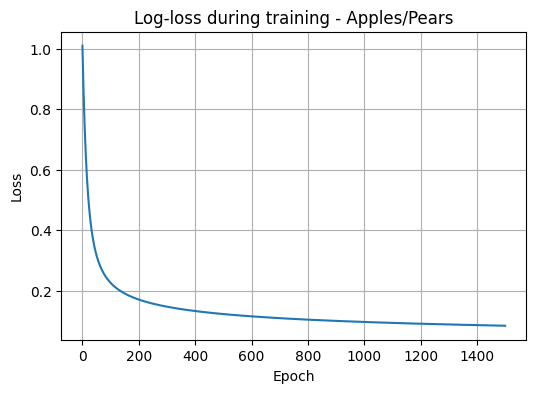

In [36]:
model_apples = train_and_evaluate(df_apples, "target", "Apples/Pears")

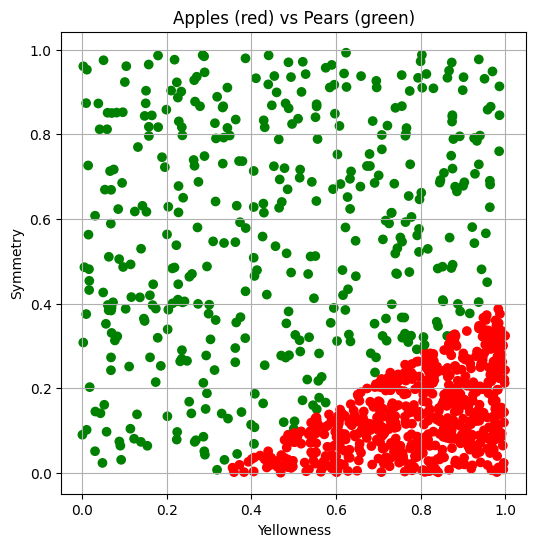

In [37]:
# Визуализация границы решения для apples/pears
plt.figure(figsize=(6, 6))

colors = df_apples["target"].map({0: "green", 1: "red"})

plt.scatter(
    df_apples["yellowness"],
    df_apples["symmetry"],
    c=colors,
)

plt.xlabel("Yellowness")
plt.ylabel("Symmetry")
plt.title("Apples (red) vs Pears (green)")
plt.grid(True)
plt.show()

### Voice

DATASET: Voice Gender
Accuracy: 0.9789695057833859
LogLoss: 0.09665086444037566
ROC-AUC: 0.9909868263896876


/tmp/ipython-input-2128152406.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr)


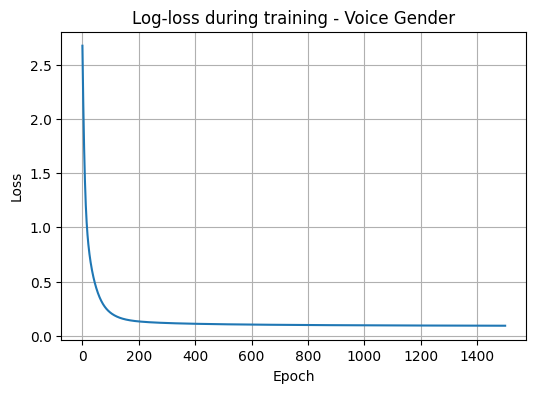

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [38]:
model_voice, scaler_voice = train_and_evaluate(df_voice, "label", "Voice Gender")

X_voice_scaled = scaler_voice.transform(df_voice.drop("label", axis=1))
y_proba = model_voice.predict_proba(X_voice_scaled)
y_pred = (y_proba >= 0.5).astype(int)
y_true = df_voice["label"].values

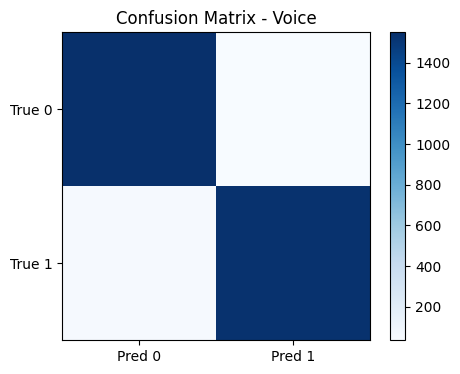

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Voice")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.show()

# Сравним с sklearn.linear_model.Perceptron

In [40]:
df = pd.read_csv("apples_pears.csv")
X = df[["symmetry", "yellowness"]]
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Инициализация
clf = Perceptron(
    max_iter=1000,
    eta0=0.1,
    tol=1e-3,
    random_state=42
)

# Обучение
clf.fit(X_scaled, y)

# Предикт
y_pred = clf.predict(X_scaled)

# Оценка
print("Accuracy:", accuracy_score(y, y_pred))
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))


Accuracy: 0.988
[[402  10]
 [  2 586]]
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       412
         1.0       0.98      1.00      0.99       588

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [41]:
df = pd.read_csv("voice.csv")

X = df.drop("label", axis=1)
y = (df["label"] == "male").astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = Perceptron(max_iter=2000, eta0=0.001, random_state=42)
clf.fit(X_scaled, y)

pred = clf.predict(X_scaled)

print("Accuracy:", accuracy_score(y, pred))
print(confusion_matrix(y, pred))
print(classification_report(y, pred))


Accuracy: 0.9217171717171717
[[1473  111]
 [ 137 1447]]
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1584
           1       0.93      0.91      0.92      1584

    accuracy                           0.92      3168
   macro avg       0.92      0.92      0.92      3168
weighted avg       0.92      0.92      0.92      3168



## Выводы по результатам
1. Apples/Pears

Neuron:

- Accuracy ≈ 0.957
- LogLoss ≈ 0.098
- ROC-AUC ≈ 0.998

Одного нейрона (логистического классификатора) полностью достаточно для разделения яблок и груш - признаки yellowness и symmetry линейно разделимы. Модель не путается в границах.

Perceptron:

- Accuracy ≈ 0.988
- Матрица ошибок показывает всего 12 ошибок из 1000 наблюдений.

Оба подхода работают почти идеально.
Данные настолько хорошо отделяются линейной границей, что даже один нейрон или перцептрон достигает почти максимального качества.

2. Voice Gender

Neuron:

- Accuracy ≈ 0.979
- LogLoss ≈ 0.097
- ROC-AUC ≈ 0.991

Несмотря на то, что данные многомерные (≈20 признаков), один нейрон очень хорошо работает.

Модель уверенно отделяет классы. Confusion matrix показывает очень малое количество ошибок.

Perceptron:

- Accuracy ≈ 0.922
- Ошибок заметно больше: 248 из 3168.

В отличие от логистического нейрона, sklearn.Perceptron использует хуже работает на слабо линейно разделимых данных.

Perceptron из sklearn обеспечивает лишь ≈92% accuracy, что показывает: перцептрон не так хорошо подходит для многомерных, неидеально линейно разделимых данных.